In [39]:
import numpy as np
import matplotlib.pyplot as plt


In [40]:
#Read the dataset
train = np.loadtxt('click.csv', delimiter= ',', skiprows= 1)
train_x = train[:, 0]
train_y = train[:, 1]


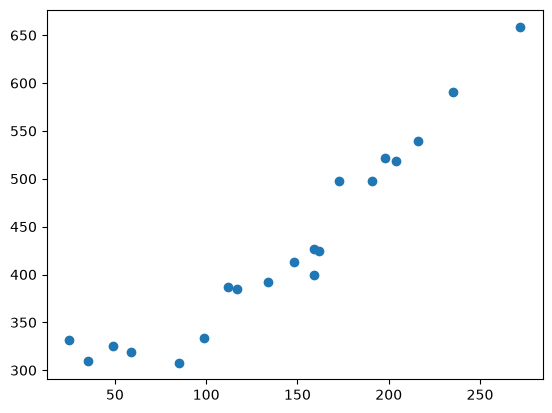

In [41]:
#Draw the picture
plt.plot(train_x, train_y, 'o')
plt.show()

In [42]:
#Parameter initialization
theta0 = np.random.rand()
theta1 = np.random.rand()

#Prediction function
def f(x):
    return theta0 + theta1 * x

#Objective funtion
def E(x, y):
    return 0.5 * np.sum((y - f(x)) ** 2)

#Standardization
mu = train_x.mean()
sigma = train_x.std()
train_z = (train_x - mu) / sigma

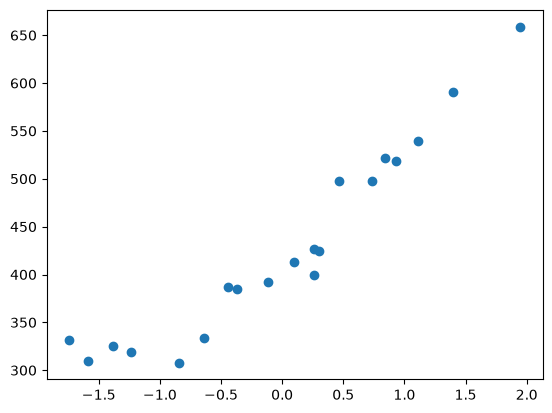

In [43]:
plt.plot(train_z, train_y, 'o')
plt.show()

In [44]:
ETA = 1e-3
diff = 1
count = 0
error = E(train_z, train_y)

while diff > 1e-2:
    tmp0 = theta0 - ETA * np.sum(f(train_z) - train_y)
    tmp1 = theta1 - ETA * np.sum((f(train_z) - train_y) * train_z)
    theta0 = tmp0
    theta1 = tmp1
    current_error = E(train_z, train_y)
    diff = error - current_error
    error = current_error
    count += 1
    log = '第{}次：theta0 = {:.3f}, theta1 = {:.3f}, 差值={:.4f}'
    print(log.format(count, theta0, theta1, diff))




第1次：theta0 = 8.811, theta1 = 1.943, 差值=76306.8493
第2次：theta0 = 17.218, theta1 = 3.773, 差值=73285.0981
第3次：theta0 = 25.457, theta1 = 5.567, 差值=70383.0082
第4次：theta0 = 33.531, theta1 = 7.326, 差值=67595.8411
第5次：theta0 = 41.443, theta1 = 9.049, 差值=64919.0458
第6次：theta0 = 49.197, theta1 = 10.737, 差值=62348.2516
第7次：theta0 = 56.796, theta1 = 12.392, 差值=59879.2608
第8次：theta0 = 64.243, theta1 = 14.014, 差值=57508.0421
第9次：theta0 = 71.541, theta1 = 15.603, 差值=55230.7236
第10次：theta0 = 78.694, theta1 = 17.161, 差值=53043.5870
第11次：theta0 = 85.703, theta1 = 18.687, 差值=50943.0609
第12次：theta0 = 92.572, theta1 = 20.183, 差值=48925.7157
第13次：theta0 = 99.303, theta1 = 21.649, 差值=46988.2574
第14次：theta0 = 105.900, theta1 = 23.085, 差值=45127.5224
第15次：theta0 = 112.365, theta1 = 24.493, 差值=43340.4725
第16次：theta0 = 118.701, theta1 = 25.873, 差值=41624.1898
第17次：theta0 = 124.910, theta1 = 27.225, 差值=39975.8719
第18次：theta0 = 130.995, theta1 = 28.550, 差值=38392.8273
第19次：theta0 = 136.958, theta1 = 29.849, 差值=36872.4714
第2

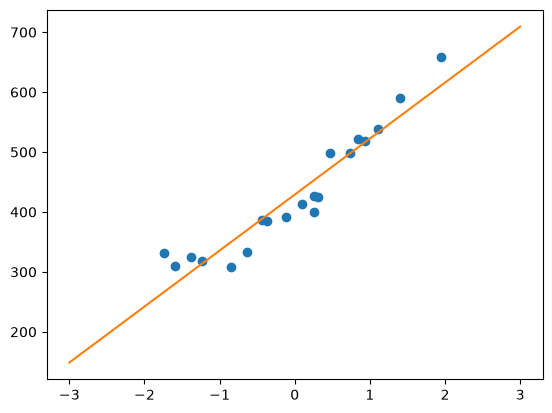

In [45]:
x = np.linspace(-3, 3, 100)
plt.plot(train_z, train_y, 'o')
plt.plot(x, f(x))
plt.show()


In [46]:
print(f((100 - mu) / sigma))
print(f((200 - mu) / sigma))
print(f((300 - mu) / sigma))

370.9672548442077
510.46958059237716
649.9719063405466


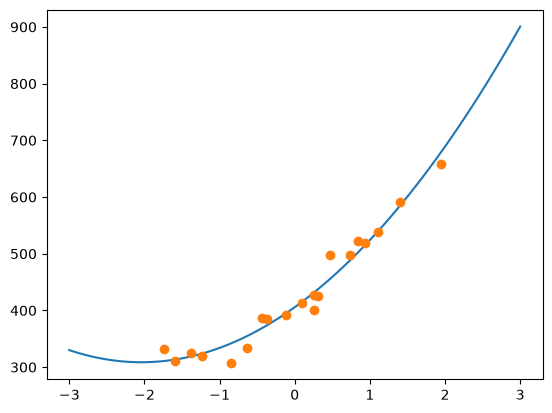

In [47]:
#Parameter initialization
theta = np.random.rand(3)

#Create a matrix for the train dataset
def to_matrix(x):
    return np.vstack([np.ones(x.shape[0]), x, x ** 2]).T

X = to_matrix(train_z)

#Prediction function
def f(x):
    return np.dot(x, theta)

diff = 1
error = E(X ,train_y)


while diff > 1e-2:
    theta = theta - ETA * np.dot(f(X) - train_y, X)
    current_error = E(X, train_y)
    diff = error - current_error
    error = current_error


x = np.linspace(-3, 3, 100)
plt.plot(x, f(to_matrix(x)))
plt.plot(train_z, train_y, 'o')
plt.show()

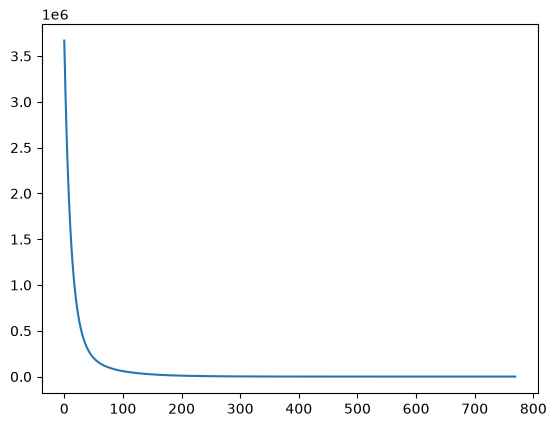

In [48]:
#Mean Square Error
def MSE(x, y):
    return (1 / x.shape[0]) * np.sum(f(x) - y) ** 2

theta = np.random.rand(3)

#The record of MSE
errors = []
diff = 1
errors.append(MSE(X, train_y))

while diff > 1e-2:
    theta = theta - ETA * np.dot(f(X) - train_y, X)
    errors.append(MSE(X, train_y))
    diff = errors[-2] - errors[-1]

#Plot the error curve
x = np.arange(len(errors))
plt.plot(x, errors)
plt.show()

In [ ]:
#随机梯度下降法
